In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay


In [24]:
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
svm_linear = SVC(
    kernel="rbf",
    random_state=42
)

svm_linear.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [27]:
train_pred = svm_linear.predict(X_train)
test_pred = svm_linear.predict(X_test)

In [28]:
train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

print(f"\nTrain F1 Score : {train_f1:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")

Train Accuracy : 0.9824
Test Accuracy  : 0.9825

Train F1 Score : 0.9861
Test F1 Score  : 0.9861


In [29]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [30]:
cm = confusion_matrix(y_test, test_pred)
print(cm)

[[41  1]
 [ 1 71]]


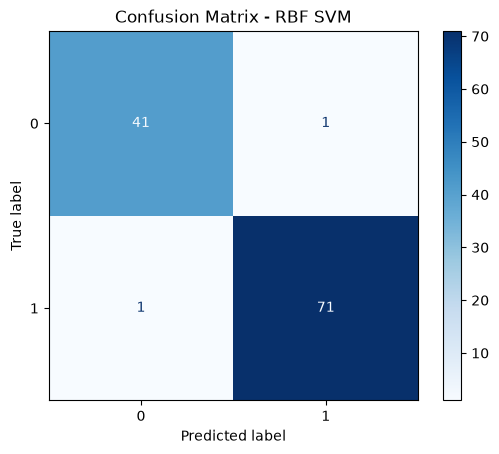

In [31]:
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix - RBF SVM")
plt.show()

# Summary

A Support Vector Machine (SVM) classifier with an RBF (Radial Basis Function) kernel was trained on the Breast Cancer Wisconsin dataset. Since SVM relies on distance calculations, the features were standardized using StandardScaler before training.

The RBF kernel enables the model to learn non-linear decision boundaries, making it suitable for datasets where the classes are not perfectly linearly separable.

The model achieved a **training accuracy of 98.24%** and a **testing accuracy of 98.25%**. Both the training and testing **F1 scores were 0.9861**, indicating excellent classification performance and strong generalization.

The confusion matrix shows that only **2 out of 114 test samples** were misclassified, demonstrating the effectiveness of the RBF kernel on this dataset.

**Final Results:**
- Train Accuracy: **98.24%**
- Test Accuracy: **98.25%**
- Train F1 Score: **0.9861**
- Test F1 Score: **0.9861**

**Conclusion:**
The RBF SVM achieved excellent performance with nearly identical training and testing scores, indicating that the model generalizes well without signs of overfitting or underfitting. The classifier was able to correctly classify almost all test samples while maintaining balanced performance across both classes.

## Comparison between Linear SVM and RBF SVM

Linear SVM performed exceptionally well because the Breast Cancer dataset is close to linearly separable.

RBF SVM achieved a slightly better test performance (98.25% vs. 97.37%) and correctly classified one additional sample.

Both models generalized well, but RBF SVM produced the highest testing Accuracy and F1 score, making it the better-performing model on this dataset.